In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from interpret import set_visualize_provider
from interpret import show
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingClassifier

from utils2 import *
from stat_utils import *

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore')
set_visualize_provider(InlineProvider())


In [2]:
df = pd.read_csv('../data/fraud_oracle.csv')

In [3]:
address_change_mapping = {
    '1 year' : "change",
    'no change' : "no_change",
    '4 to 8 years' : "change", 
    '2 to 3 years' : "change",
    'under 6 months' : "change"
}
vehicle_price_mapping = {
    'less than 20000': "less than 30000",
    '20000 to 29000': "less than 30000",
    '30000 to 39000': "30000 to 59000",
    '40000 to 59000': "30000 to 59000",
    '60000 to 69000': "more than 60000",
    'more than 69000': "more than 60000"
}

df['AddressChange_Claim_2'] = df['AddressChange_Claim'].map(address_change_mapping)
df['VehiclePrice_num'] = df['VehiclePrice'].map(vehicle_price_mapping)

In [4]:
time_vars = ["Month", "WeekOfMonth", "DayOfWeek", "DayOfWeekClaimed", 'MonthClaimed', 'WeekOfMonthClaimed']
vehicle_vars = ["Make", "VehiclePrice_num", "VehicleCategory", "AgeOfVehicle"]
personal_vars = ["Sex", 'MaritalStatus', "Age", 'DriverRating', 'AgeOfPolicyHolder', 'NumberOfCars', 'PastNumberOfClaims']
policy_vars = ["PolicyType", 'Deductible', 'AgentType', "NumberOfSuppliments"]
accident_vars = ['Days_Policy_Accident', 'Days_Policy_Claim', 'PoliceReportFiled', 'WitnessPresent', 'AddressChange_Claim_2']

In [5]:
collision = df.loc[df['BasePolicy']=="Collision"]
liability = df.loc[df['BasePolicy']=="Liability"]
all_p = df.loc[df['BasePolicy']=="All Perils"]

In [6]:
target_col = "FraudFound_P"
X = collision[vehicle_vars + personal_vars + policy_vars + accident_vars]
y = collision[target_col].astype(int)

In [7]:
seed = 42
np.random.seed(seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

In [8]:
ebm = ExplainableBoostingClassifier(interactions=False)
ebm.fit(X_train, y_train)

ExplainableBoostingClassifier(interactions=False)

In [9]:
y_pred = ebm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1109
           1       0.00      0.00      0.00        84

    accuracy                           0.93      1193
   macro avg       0.46      0.50      0.48      1193
weighted avg       0.86      0.93      0.90      1193



In [10]:
collision.FraudFound_P.value_counts()

FraudFound_P
0    5527
1     435
Name: count, dtype: int64

### Oversampling
- https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC

In [11]:
df.BasePolicy.value_counts()

BasePolicy
Collision     5962
Liability     5009
All Perils    4449
Name: count, dtype: int64

In [12]:
target_col = "FraudFound_P"

In [13]:
all_p.FraudFound_P.value_counts()

FraudFound_P
0    3997
1     452
Name: count, dtype: int64

In [27]:
from imblearn.over_sampling import SMOTENC

X = all_p[vehicle_vars + personal_vars + policy_vars + accident_vars]
y = all_p[target_col].astype(int)

categorical_features = [X.columns.get_loc(col) for col in X.select_dtypes(include=['object']).columns]

smote_nc = SMOTENC(categorical_features=categorical_features, random_state=42, sampling_strategy={0:len(y[y == 0]),
                                                                                                  1:3000})

X = X.values

# Apply SMOTENC
X_resampled, y_resampled = smote_nc.fit_resample(X, y)

X_resampled = pd.DataFrame(X_resampled, columns=vehicle_vars + personal_vars + policy_vars + accident_vars)

In [29]:
X_resampled

,Make,VehiclePrice_num,VehicleCategory,AgeOfVehicle,Sex,MaritalStatus,Age,DriverRating,AgeOfPolicyHolder,NumberOfCars,PastNumberOfClaims,PolicyType,Deductible,AgentType,NumberOfSuppliments,Days_Policy_Accident,Days_Policy_Claim,PoliceReportFiled,WitnessPresent,AddressChange_Claim_2
0,Ford,more than 60000,Utility,more than 7,Male,Married,42.0,1.0,36 to 40,1 vehicle,2 to 4,Utility - All Perils,400.0,External,3 to 5,more than 30,more than 30,No,No,no_change
1,Mazda,more than 60000,Sedan,more than 7,Male,Single,71.0,3.0,over 65,1 vehicle,none,Sedan - All Perils,400.0,External,none,more than 30,more than 30,No,No,no_change
2,Ford,more than 60000,Sedan,7 years,Male,Married,41.0,4.0,36 to 40,1 vehicle,none,Sedan - All Perils,400.0,External,none,more than 30,more than 30,No,No,no_change
3,Mazda,more than 60000,Sedan,more than 7,Male,Married,45.0,3.0,36 to 40,1 vehicle,more than 4,Sedan - All Perils,400.0,External,none,more than 30,more than 30,Yes,No,no_change
4,Accura,30000 to 59000,Sedan,7 years,Male,Married,42.0,3.0,36 to 40,1 vehicle,2 to 4,Sedan - All Perils,400.0,External,1 to 2,more than 30,more than 30,No,No,no_change
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6992,Pontiac,less than 30000,Sedan,7 years,Male,Married,41.487452,2.0,36 to 40,1 vehicle,1,Sedan - All Perils,400.0,External,3 to 5,more than 30,more than 30,No,No,no_change
6993,Pontiac,less than 30000,Sedan,more than 7,Male,Married,69.04885,2.016283,over 65,1 vehicle,1,Sedan - All Perils,400.0,External,none,more than 30,more than 30,No,No,no_change
6994,Chevrolet,less than 30000,Sedan,5 years,Male,Single,31.860724,2.0,31 to 35,1 vehicle,1,Sedan - All Perils,400.0,External,none,more than 30,more than 30,No,No,no_change
6995,Accura,more than 60000,Utility,more than 7,Male,Married,58.566774,3.522258,51 to 65,1 vehicle,none,Utility - All Perils,400.0,External,none,more than 30,more than 30,No,No,no_change


In [30]:
int_columns = all_p.select_dtypes(include=['int64', 'int32']).columns

for i in int_columns:
    if i in X_resampled.columns:
        X_resampled[i] = X_resampled[i].astype(int)

In [31]:
X_resampled

,Make,VehiclePrice_num,VehicleCategory,AgeOfVehicle,Sex,MaritalStatus,Age,DriverRating,AgeOfPolicyHolder,NumberOfCars,PastNumberOfClaims,PolicyType,Deductible,AgentType,NumberOfSuppliments,Days_Policy_Accident,Days_Policy_Claim,PoliceReportFiled,WitnessPresent,AddressChange_Claim_2
0,Ford,more than 60000,Utility,more than 7,Male,Married,42,1,36 to 40,1 vehicle,2 to 4,Utility - All Perils,400,External,3 to 5,more than 30,more than 30,No,No,no_change
1,Mazda,more than 60000,Sedan,more than 7,Male,Single,71,3,over 65,1 vehicle,none,Sedan - All Perils,400,External,none,more than 30,more than 30,No,No,no_change
2,Ford,more than 60000,Sedan,7 years,Male,Married,41,4,36 to 40,1 vehicle,none,Sedan - All Perils,400,External,none,more than 30,more than 30,No,No,no_change
3,Mazda,more than 60000,Sedan,more than 7,Male,Married,45,3,36 to 40,1 vehicle,more than 4,Sedan - All Perils,400,External,none,more than 30,more than 30,Yes,No,no_change
4,Accura,30000 to 59000,Sedan,7 years,Male,Married,42,3,36 to 40,1 vehicle,2 to 4,Sedan - All Perils,400,External,1 to 2,more than 30,more than 30,No,No,no_change
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6992,Pontiac,less than 30000,Sedan,7 years,Male,Married,41,2,36 to 40,1 vehicle,1,Sedan - All Perils,400,External,3 to 5,more than 30,more than 30,No,No,no_change
6993,Pontiac,less than 30000,Sedan,more than 7,Male,Married,69,2,over 65,1 vehicle,1,Sedan - All Perils,400,External,none,more than 30,more than 30,No,No,no_change
6994,Chevrolet,less than 30000,Sedan,5 years,Male,Single,31,2,31 to 35,1 vehicle,1,Sedan - All Perils,400,External,none,more than 30,more than 30,No,No,no_change
6995,Accura,more than 60000,Utility,more than 7,Male,Married,58,3,51 to 65,1 vehicle,none,Utility - All Perils,400,External,none,more than 30,more than 30,No,No,no_change


In [32]:
all_p_resampled = pd.concat([X_resampled, y_resampled], axis=1)

In [33]:
all_p_resampled.FraudFound_P.value_counts()

FraudFound_P
0    3997
1    3000
Name: count, dtype: int64

In [34]:
X = all_p_resampled[vehicle_vars + personal_vars + policy_vars + accident_vars]
y = all_p_resampled["FraudFound_P"].astype(int)

seed = 42
np.random.seed(seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

ebm = ExplainableBoostingClassifier(interactions=False, random_state=42)
ebm.fit(X_train, y_train)

y_pred = ebm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

Create predictions

In [36]:
print(report)

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       796
           1       0.61      0.59      0.60       604

    accuracy                           0.66      1400
   macro avg       0.66      0.65      0.65      1400
weighted avg       0.66      0.66      0.66      1400



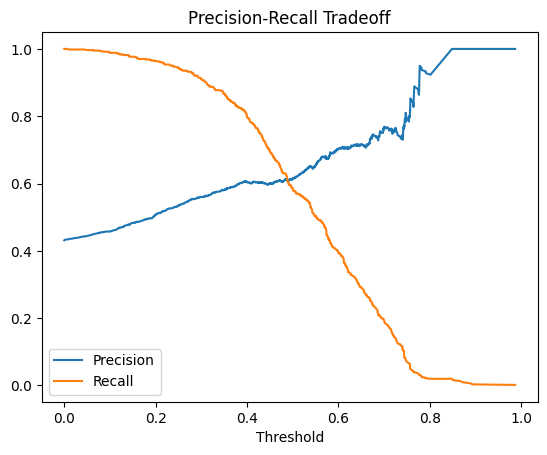

In [37]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = ebm.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall Tradeoff')
plt.show()

In [38]:
show(ebm.explain_global())

In [39]:
show(ebm.explain_local(X_test[:5], y_test[:5]), 0)

# collision modeling

In [45]:
from imblearn.over_sampling import SMOTENC

X = collision[vehicle_vars + personal_vars + policy_vars + accident_vars]
y = collision[target_col].astype(int)

categorical_features = [X.columns.get_loc(col) for col in X.select_dtypes(include=['object']).columns]

smote_nc = SMOTENC(categorical_features=categorical_features, random_state=42, sampling_strategy={0:len(y[y == 0]),
                                                                                                  1:3000})

X = X.values

# Apply SMOTENC
X_resampled, y_resampled = smote_nc.fit_resample(X, y)

X_resampled = pd.DataFrame(X_resampled, columns=vehicle_vars + personal_vars + policy_vars + accident_vars)

In [47]:
int_columns = collision.select_dtypes(include=['int64', 'int32']).columns

for i in int_columns:
    if i in X_resampled.columns:
        X_resampled[i] = X_resampled[i].astype(int)

In [48]:
collision_resampled = pd.concat([X_resampled, y_resampled], axis=1)

In [49]:
collision_resampled.FraudFound_P.value_counts()

FraudFound_P
0    5527
1    3000
Name: count, dtype: int64

In [53]:
X = collision_resampled[vehicle_vars + personal_vars + policy_vars + accident_vars]
y = collision_resampled["FraudFound_P"].astype(int)

seed = 42
np.random.seed(seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

ebm = ExplainableBoostingClassifier(interactions=False)
ebm.fit(X_train, y_train)

y_pred = ebm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.74      0.88      0.80      1109
           1       0.65      0.43      0.52       597

    accuracy                           0.72      1706
   macro avg       0.70      0.65      0.66      1706
weighted avg       0.71      0.72      0.70      1706



In [54]:
show(ebm.explain_global())

In [55]:
show(ebm.explain_local(X_test[:5], y_test[:5]), 0)